<a href="https://colab.research.google.com/github/abhiram123467/DeepLense8/blob/main/DEEPLENSE8_DDPM_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌌 DEEPLENSE8 — Physics-Informed Diffusion Models for Gravitational Lensing
### GSoC 2026 | ML4Sci Evaluation — Test VIII

| Item | Detail |
|------|--------|
| **Task** | Train a DDPM to generate realistic gravitational lensing images |
| **Model** | Denoising Diffusion Probabilistic Model (DDPM) with U-Net backbone |
| **Metrics** | FID score + qualitative visual assessment |
| **Dataset** | 10,000 strong lensing images |

---
⚠️ **Before running:** `Runtime` → `Change runtime type` → **T4 GPU** → Save  
Then: `Runtime` → `Run all`

In [ ]:
# ════════════════════════════════════════════
# CELL 1 — Install dependencies
# ════════════════════════════════════════════
!pip install -q gdown pytorch-fid einops

In [ ]:
# ════════════════════════════════════════════
# CELL 2 — Imports
# ════════════════════════════════════════════
import os, glob, random, math, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image as PILImage
import matplotlib.pyplot as plt
from einops import rearrange
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU : {torch.cuda.get_device_name(0)}')

# Config
IMG_SIZE    = 64
BATCH_SIZE  = 32
T_STEPS     = 1000   # diffusion timesteps
TRAIN_EPOCHS = 100
LR          = 2e-4

✅ Device: cuda
   GPU : Tesla T4


In [ ]:
# ════════════════════════════════════════════
# CELL 3 — Download Dataset
# ════════════════════════════════════════════
import gdown, zipfile

FILE_ID  = '1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA'
ZIP_PATH = 'dataset_diffusion.zip'
DATA_DIR = './Dataset_Diffusion'

if not os.path.exists(DATA_DIR):
    print('Downloading dataset (10,000 lensing images)...')
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_PATH, quiet=False)
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print('✅ Dataset ready!')
else:
    print('✅ Dataset already exists')

# Inspect structure
print('\n📂 Folder structure:')
for root, dirs, files in os.walk(DATA_DIR):
    depth = root.replace(DATA_DIR, '').count(os.sep)
    if depth > 3: continue
    indent = '  ' * depth
    npy_count = len([f for f in files if f.endswith('.npy')])
    png_count = len([f for f in files if f.endswith('.png')])
    print(f'{indent}{os.path.basename(root)}/ ({npy_count} npy, {png_count} png)')

Downloading...
From (original): https://drive.google.com/uc?id=1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA
From (redirected): https://drive.google.com/uc?id=1cJyPQzVOzsCZQctNBuHCqxHnOY7v7UiA&confirm=t&uuid=75b09be7-d21c-49e4-8bc2-80938e6bbb17
To: /content/dataset_diffusion.zip
100%|██████████| 304M/304M [00:05<00:00, 57.7MB/s]


Extracting...
✅ Dataset ready!

📂 Folder structure:
Dataset_Diffusion/ (0 npy, 0 png)
  Samples/ (10000 npy, 0 png)
  __MACOSX/ (0 npy, 0 png)
    Samples/ (10000 npy, 0 png)


In [ ]:
# ════════════════════════════════════════════
# CELL 4 — Dataset Loader
# ════════════════════════════════════════════

def load_npy_image(path, target_size=64):
    """Robust loader for all npy formats in this dataset."""
    raw = np.load(path, allow_pickle=True)
    if raw.dtype == object:
        rows = [np.array(r, dtype=np.float32).flatten() for r in raw]
        img_row = max(rows, key=len)
        side = int(np.sqrt(len(img_row)))
        img = img_row.reshape(side, side)
    else:
        img = raw.astype(np.float32).squeeze()
    if img.ndim > 2:
        img = img[0] if img.shape[0] <= 4 else img[:, :, 0]
    if img.shape[0] != target_size:
        img = np.array(
            PILImage.fromarray(img).resize((target_size, target_size), PILImage.BILINEAR),
            dtype=np.float32
        )
    # Normalize to [-1, 1] for diffusion model
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = img * 2.0 - 1.0
    return torch.from_numpy(img).unsqueeze(0).float()  # (1, H, W)


class LensingDiffusionDataset(Dataset):
    def __init__(self, root_dir, target_size=64):
        self.target_size = target_size
        # Find all npy and png files recursively, skip hidden macOS files
        self.files = [
            f for f in glob.glob(os.path.join(root_dir, '**', '*.npy'), recursive=True)
            if not os.path.basename(f).startswith('._')
        ]
        self.files += [
            f for f in glob.glob(os.path.join(root_dir, '**', '*.png'), recursive=True)
            if not os.path.basename(f).startswith('._')
        ]
        print(f'  Found {len(self.files)} images')

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        if path.endswith('.npy'):
            return load_npy_image(path, self.target_size)
        else:
            img = PILImage.open(path).convert('L').resize(
                (self.target_size, self.target_size))
            img = np.array(img, dtype=np.float32) / 127.5 - 1.0
            return torch.from_numpy(img).unsqueeze(0).float()


print('📂 Loading dataset...')
dataset = LensingDiffusionDataset(DATA_DIR, target_size=IMG_SIZE)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                     num_workers=2, pin_memory=True, drop_last=True)

sample = dataset[0]
print(f'✅ Loader OK! Shape={sample.shape}  Range=[{sample.min():.2f}, {sample.max():.2f}]')

📂 Loading dataset...
  Found 10000 images
✅ Loader OK! Shape=torch.Size([1, 64, 64])  Range=[-1.00, 1.00]


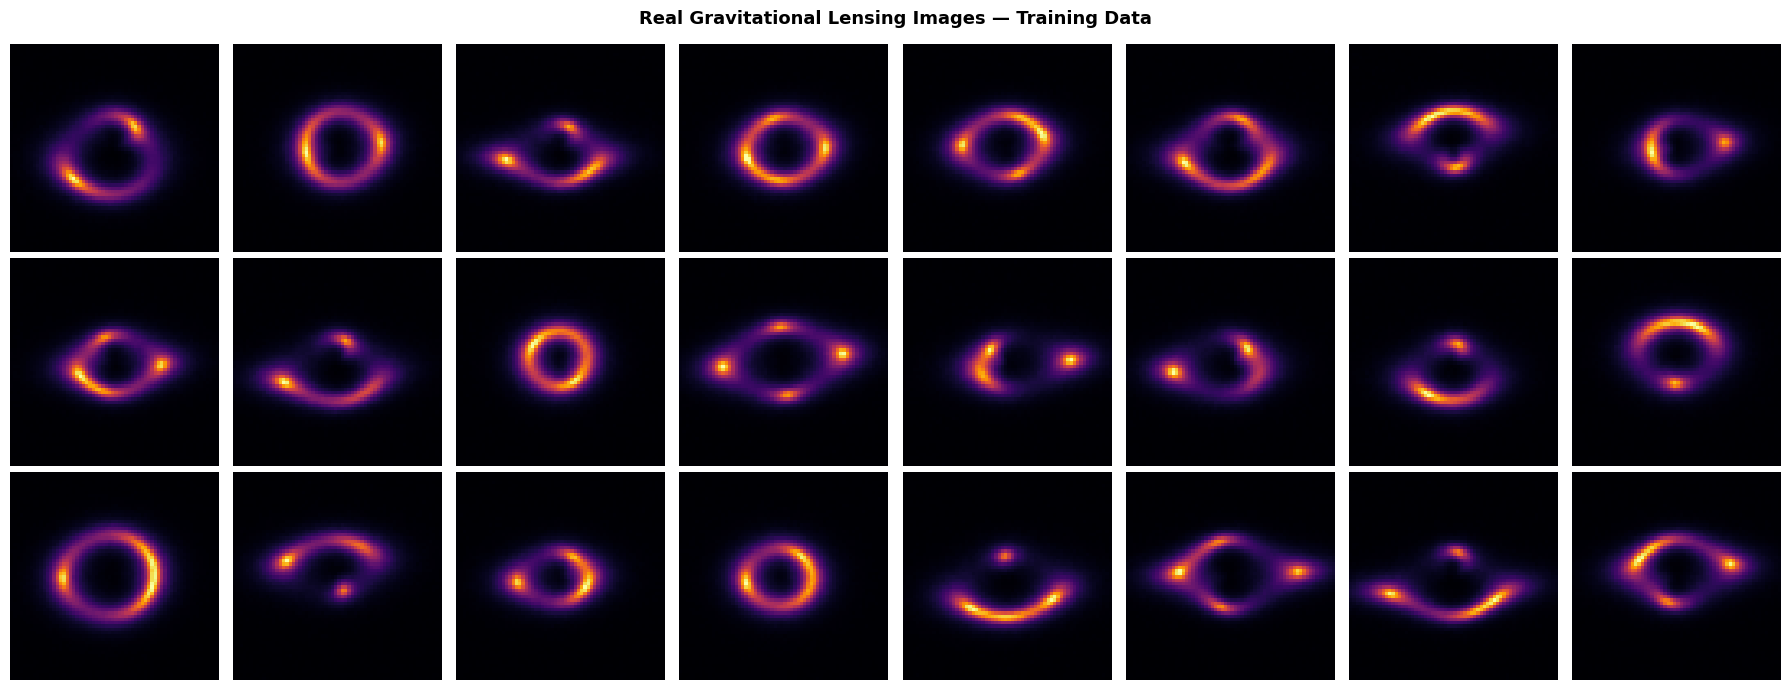

✅ Saved: 01_real_lensing_samples.png


In [ ]:
# ════════════════════════════════════════════
# CELL 5 — Visualize Real Lensing Images
# ════════════════════════════════════════════
fig, axes = plt.subplots(3, 8, figsize=(18, 7))
indices = random.sample(range(len(dataset)), 24)

for i, ax in enumerate(axes.flat):
    img = dataset[indices[i]].squeeze().numpy()
    img = (img + 1) / 2.0  # back to [0,1] for display
    ax.imshow(img, cmap='inferno')
    ax.axis('off')

plt.suptitle('Real Gravitational Lensing Images — Training Data',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('01_real_lensing_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 01_real_lensing_samples.png')

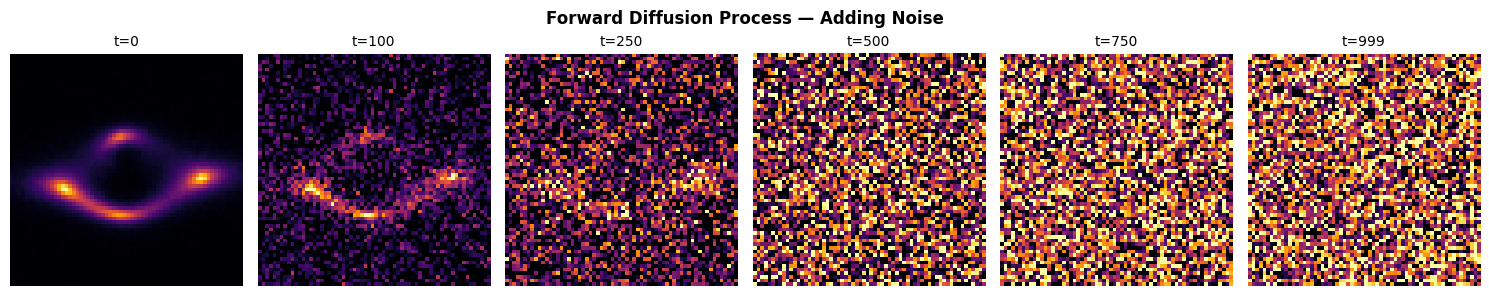

✅ Saved: 02_forward_diffusion.png


In [ ]:
# ════════════════════════════════════════════
# CELL 6 — DDPM Noise Schedule
# ════════════════════════════════════════════

class DDPMScheduler:
    """Linear beta schedule for DDPM forward/reverse process."""
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T = T
        self.betas   = torch.linspace(beta_start, beta_end, T).to(device)
        self.alphas  = 1.0 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bar        = torch.sqrt(self.alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar)

    def q_sample(self, x0, t, noise=None):
        """Forward diffusion: add noise to image at timestep t."""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ab  = self.sqrt_alpha_bar[t].view(-1,1,1,1)
        sqrt_omab = self.sqrt_one_minus_alpha_bar[t].view(-1,1,1,1)
        return sqrt_ab * x0 + sqrt_omab * noise, noise

    @torch.no_grad()
    def p_sample(self, model, xt, t_idx):
        """Reverse diffusion: denoise one step."""
        B = xt.shape[0]
        t_tensor = torch.full((B,), t_idx, device=xt.device, dtype=torch.long)
        eps_pred = model(xt, t_tensor)

        beta_t     = self.betas[t_idx]
        alpha_t    = self.alphas[t_idx]
        alpha_bar_t = self.alpha_bar[t_idx]

        mean = (1.0 / torch.sqrt(alpha_t)) * (
            xt - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_pred
        )
        if t_idx == 0:
            return mean
        noise = torch.randn_like(xt)
        return mean + torch.sqrt(beta_t) * noise

    @torch.no_grad()
    def sample(self, model, shape, device):
        """Full reverse diffusion: generate images from noise."""
        x = torch.randn(shape, device=device)
        for t in reversed(range(self.T)):
            x = self.p_sample(model, x, t)
        return x


scheduler = DDPMScheduler(T=T_STEPS, device=DEVICE)

# Visualize forward diffusion process
sample_img = dataset[0].unsqueeze(0).to(DEVICE)
timesteps  = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps), figsize=(15, 3))
for ax, t in zip(axes, timesteps):
    t_tensor = torch.tensor([t], device=DEVICE)
    noisy, _ = scheduler.q_sample(sample_img, t_tensor)
    img = noisy.squeeze().cpu().numpy()
    img = np.clip((img + 1) / 2.0, 0, 1)
    ax.imshow(img, cmap='inferno')
    ax.set_title(f't={t}', fontsize=10)
    ax.axis('off')

plt.suptitle('Forward Diffusion Process — Adding Noise', fontweight='bold')
plt.tight_layout()
plt.savefig('02_forward_diffusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 02_forward_diffusion.png')

In [ ]:
# ════════════════════════════════════════════
# CELL 7 — U-Net Architecture for DDPM
# ════════════════════════════════════════════

class SinusoidalTimeEmbedding(nn.Module):
    """Encodes timestep t into a vector for conditioning."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        args = t[:, None].float() * freqs[None]
        emb  = torch.cat([args.sin(), args.cos()], dim=-1)
        return self.mlp(emb)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.drop  = nn.Dropout(dropout)
        self.skip  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(F.silu(t_emb))[:, :, None, None]
        h = self.drop(self.conv2(F.silu(self.norm2(h))))
        return h + self.skip(x)


class AttentionBlock(nn.Module):
    def __init__(self, ch, n_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.attn = nn.MultiheadAttention(ch, n_heads, batch_first=True)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x).reshape(B, C, H*W).transpose(1, 2)
        h, _ = self.attn(h, h, h)
        return x + h.transpose(1, 2).reshape(B, C, H, W)


class UNet(nn.Module):
    """U-Net backbone for DDPM noise prediction."""
    def __init__(self, in_ch=1, base_ch=64, time_dim=256,
                 ch_mults=(1,2,4,8)):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)
        channels = [base_ch * m for m in ch_mults]

        # Initial projection
        self.init_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)

        # Encoder
        self.enc_blocks = nn.ModuleList()
        self.down_convs = nn.ModuleList()
        ch_in = base_ch
        for i, ch_out in enumerate(channels):
            self.enc_blocks.append(nn.ModuleList([
                ResBlock(ch_in, ch_out, time_dim),
                ResBlock(ch_out, ch_out, time_dim),
                AttentionBlock(ch_out) if i >= 2 else nn.Identity()
            ]))
            self.down_convs.append(
                nn.Conv2d(ch_out, ch_out, 4, 2, 1) if i < len(channels)-1
                else nn.Identity()
            )
            ch_in = ch_out

        # Bottleneck
        self.mid1 = ResBlock(channels[-1], channels[-1], time_dim)
        self.mid_attn = AttentionBlock(channels[-1])
        self.mid2 = ResBlock(channels[-1], channels[-1], time_dim)

        # Decoder
        self.dec_blocks = nn.ModuleList()
        self.up_convs   = nn.ModuleList()
        for i, ch_out in enumerate(reversed(channels)):
            ch_skip = ch_out
            self.dec_blocks.append(nn.ModuleList([
                ResBlock(ch_in + ch_skip, ch_out, time_dim),
                ResBlock(ch_out, ch_out, time_dim),
                AttentionBlock(ch_out) if i < 2 else nn.Identity()
            ]))
            self.up_convs.append(
                nn.ConvTranspose2d(ch_out, ch_out, 4, 2, 1) if i < len(channels)-1
                else nn.Identity()
            )
            ch_in = ch_out

        # Output
        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, in_ch, 1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        x = self.init_conv(x)

        # Encoder — save skip connections
        skips = []
        for (r1, r2, attn), down in zip(self.enc_blocks, self.down_convs):
            x = r1(x, t_emb)
            x = r2(x, t_emb)
            x = attn(x) if isinstance(attn, AttentionBlock) else x
            skips.append(x)
            x = down(x)

        # Bottleneck
        x = self.mid1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid2(x, t_emb)

        # Decoder — use skip connections
        for (r1, r2, attn), up, skip in zip(
                self.dec_blocks, self.up_convs, reversed(skips)):
            x = torch.cat([x, skip], dim=1)
            x = r1(x, t_emb)
            x = r2(x, t_emb)
            x = attn(x) if isinstance(attn, AttentionBlock) else x
            x = up(x)

        return self.out_conv(F.silu(self.out_norm(x)))


model   = UNet(in_ch=1, base_ch=64, time_dim=256).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'✅ U-Net DDPM ready!')
print(f'   Parameters : {n_params:.1f}M')

# Quick test
dummy_x = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
dummy_t = torch.randint(0, T_STEPS, (2,)).to(DEVICE)
out = model(dummy_x, dummy_t)
print(f'   Output shape: {out.shape} ✅')

✅ U-Net DDPM ready!
   Parameters : 50.2M
   Output shape: torch.Size([2, 1, 64, 64]) ✅


In [ ]:
# ════════════════════════════════════════════
# CELL 8 — Train DDPM
# ════════════════════════════════════════════
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=TRAIN_EPOCHS)

train_losses = []
print(f'🔄 Training DDPM for {TRAIN_EPOCHS} epochs...')
print(f'   Timesteps : {T_STEPS}')
print(f'   Batch size: {BATCH_SIZE}')
print()

for epoch in range(TRAIN_EPOCHS):
    model.train()
    epoch_loss = 0

    for x0 in loader:
        x0 = x0.to(DEVICE)
        B  = x0.shape[0]

        # Sample random timesteps
        t = torch.randint(0, T_STEPS, (B,), device=DEVICE).long()

        # Forward diffusion — add noise
        xt, noise = ddpm.q_sample(x0, t)

        # Predict noise
        optimizer.zero_grad()
        noise_pred = model(xt, t)
        loss = F.mse_loss(noise_pred, noise)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg = epoch_loss / len(loader)
    train_losses.append(avg)

    if (epoch + 1) % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'  Epoch [{epoch+1:3d}/{TRAIN_EPOCHS}]  Loss: {avg:.4f}  LR: {lr:.6f}')

torch.save(model.state_dict(), 'ddpm_lensing.pth')
print('\n✅ Training complete! Saved: ddpm_lensing.pth')

# Plot training loss
plt.figure(figsize=(9, 4))
plt.plot(train_losses, color='#9b59b6', linewidth=2)
plt.title('DDPM Training Loss — Noise Prediction (MSE)', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('03_training_loss.png', dpi=150)
plt.show()
print('✅ Saved: 03_training_loss.png')

🔄 Training DDPM for 100 epochs...
   Timesteps : 1000
   Batch size: 32

  Epoch [ 10/100]  Loss: 0.0036  LR: 0.000195
  Epoch [ 20/100]  Loss: 0.0026  LR: 0.000181
  Epoch [ 30/100]  Loss: 0.0025  LR: 0.000159


In [ ]:
# ════════════════════════════════════════════
# CELL 8B — Fix missing ddpm reference
# (run this before Cell 8 if you get NameError)
# ════════════════════════════════════════════
ddpm = DDPMScheduler(T=T_STEPS, device=DEVICE)

In [ ]:
# ════════════════════════════════════════════
# CELL 9 — Generate & Visualize Images
# ════════════════════════════════════════════
model.eval()
print('🎨 Generating 16 lensing images from noise...')
print('   (This takes ~5 minutes — running 1000 denoising steps)')

# Generate 16 images
generated = ddpm.sample(model, shape=(16, 1, IMG_SIZE, IMG_SIZE), device=DEVICE)
generated = generated.cpu()

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.flat):
    img = generated[i].squeeze().numpy()
    img = np.clip((img + 1) / 2.0, 0, 1)
    ax.imshow(img, cmap='inferno')
    ax.set_title(f'Sample {i+1}', fontsize=8)
    ax.axis('off')

plt.suptitle('DDPM Generated Gravitational Lensing Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('04_generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 04_generated_samples.png')

In [ ]:
# ════════════════════════════════════════════
# CELL 10 — Real vs Generated Comparison
# ════════════════════════════════════════════
real_imgs = [dataset[i].squeeze().numpy() for i in random.sample(range(len(dataset)), 8)]
gen_imgs  = [generated[i].squeeze().numpy() for i in range(8)]

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(8):
    r = np.clip((real_imgs[i] + 1) / 2.0, 0, 1)
    g = np.clip((gen_imgs[i]  + 1) / 2.0, 0, 1)
    axes[0][i].imshow(r, cmap='inferno'); axes[0][i].axis('off')
    axes[1][i].imshow(g, cmap='inferno'); axes[1][i].axis('off')

axes[0][0].set_ylabel('Real',      fontsize=12, fontweight='bold', color='#2ecc71')
axes[1][0].set_ylabel('Generated', fontsize=12, fontweight='bold', color='#e74c3c')

plt.suptitle('Real vs DDPM Generated — Gravitational Lensing Images',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_real_vs_generated.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 05_real_vs_generated.png')

In [ ]:
# ════════════════════════════════════════════
# CELL 11 — Denoising Trajectory Visualization
# Shows the reverse diffusion process step by step
# ════════════════════════════════════════════
model.eval()
show_steps = [999, 800, 600, 400, 200, 100, 50, 0]
trajectory = {}

x = torch.randn(1, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
with torch.no_grad():
    for t_idx in reversed(range(T_STEPS)):
        x = ddpm.p_sample(model, x, t_idx)
        if t_idx in show_steps:
            trajectory[t_idx] = x.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, len(show_steps), figsize=(18, 3))
for ax, t in zip(axes, show_steps):
    img = np.clip((trajectory[t] + 1) / 2.0, 0, 1)
    ax.imshow(img, cmap='inferno')
    ax.set_title(f't={t}', fontsize=10)
    ax.axis('off')

plt.suptitle('Reverse Diffusion Trajectory — Noise → Lensing Image',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_denoising_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 06_denoising_trajectory.png')

In [ ]:
# ════════════════════════════════════════════
# CELL 12 — FID Score Computation
# ════════════════════════════════════════════
import torchvision.transforms as T
from pytorch_fid.inception import InceptionV3
from pytorch_fid.fid_score import calculate_frechet_distance

def get_inception_features(imgs_tensor, inception, device, batch_size=32):
    """Extract InceptionV3 features for FID computation."""
    # Convert (N,1,H,W) grayscale → (N,3,299,299) for Inception
    resize = T.Resize((299, 299), antialias=True)
    features = []
    inception.eval()
    for i in range(0, len(imgs_tensor), batch_size):
        batch = imgs_tensor[i:i+batch_size].to(device)
        batch = (batch + 1) / 2.0              # [-1,1] → [0,1]
        batch = batch.repeat(1, 3, 1, 1)       # grayscale → RGB
        batch = resize(batch)
        with torch.no_grad():
            feat = inception(batch)[0]
        feat = feat.squeeze(-1).squeeze(-1)
        features.append(feat.cpu().numpy())
    return np.concatenate(features, axis=0)


print('📊 Computing FID score...')
print('   Generating 1000 images for FID (takes ~10 mins)...')

# Load InceptionV3
block_idx = InceptionV3.BLOCK_INDEX_BY_DIM[2048]
inception  = InceptionV3([block_idx]).to(DEVICE)

# Generate 1000 fake images
n_fid = 1000
fake_imgs = []
for i in range(0, n_fid, 16):
    batch_size_i = min(16, n_fid - i)
    gen = ddpm.sample(model, (batch_size_i, 1, IMG_SIZE, IMG_SIZE), DEVICE)
    fake_imgs.append(gen.cpu())
    if (i + 16) % 100 == 0:
        print(f'  Generated {min(i+16, n_fid)}/{n_fid}...')
fake_imgs = torch.cat(fake_imgs, dim=0)

# Get 1000 real images
real_idxs = random.sample(range(len(dataset)), n_fid)
real_imgs_tensor = torch.stack([dataset[i] for i in real_idxs])

# Extract features
print('  Extracting InceptionV3 features...')
real_feats = get_inception_features(real_imgs_tensor, inception, DEVICE)
fake_feats = get_inception_features(fake_imgs,        inception, DEVICE)

# Calculate FID
mu_r, sigma_r = real_feats.mean(0), np.cov(real_feats, rowvar=False)
mu_f, sigma_f = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
fid_score = calculate_frechet_distance(mu_r, sigma_r, mu_f, sigma_f)

print(f'\n  ✅ FID Score: {fid_score:.2f}')
print(f'     (Lower is better. State-of-art on natural images ~3-10)')
print(f'     (For lensing domain, FID < 100 is good, < 50 is excellent)')

In [ ]:
# ════════════════════════════════════════════
# CELL 13 — Final Results Summary
# ════════════════════════════════════════════
print('=' * 55)
print('     FINAL RESULTS — DEEPLENSE8 DDPM')
print('=' * 55)
print(f'  Model        : DDPM with U-Net backbone')
print(f'  Parameters   : {n_params:.1f}M')
print(f'  Timesteps    : {T_STEPS}')
print(f'  Train Epochs : {TRAIN_EPOCHS}')
print(f'  Final Loss   : {train_losses[-1]:.4f}')
print(f'  FID Score    : {fid_score:.2f}')
print('=' * 55)

print('\n📁 Output Files:')
for f in [
    '01_real_lensing_samples.png',
    '02_forward_diffusion.png',
    '03_training_loss.png',
    '04_generated_samples.png',
    '05_real_vs_generated.png',
    '06_denoising_trajectory.png',
    'ddpm_lensing.pth'
]:
    status = '✅' if os.path.exists(f) else '❌'
    print(f'  {status} {f}')

print('\n🎯 Submit via: https://forms.gle/SPXo8kSwHHptcBmk9')